In [1]:
from ts_toolkit.pipeline.runner import TsPipeline
from ts_toolkit.pipeline.utils import load_config
import logging
from tqdm.notebook import tqdm
import pandas as pd
from dotenv import load_dotenv
import os

# auto reload imports in jupyter
%load_ext autoreload
%autoreload 2

/home/roc/01_projects/01_timeseries/timeseries-research/.venv/lib/python3.10/site-packages/fs/__init__.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  __import__("pkg_resources").declare_namespace(__name__)  # type: ignore


In [2]:
load_dotenv()
print(GIFT_EVAL_PATH := os.getenv("GIFT_EVAL"))
print(REPO_ROOT := os.getenv("REPO_ROOT"))

/home/roc/01_projects/01_timeseries/timeseries-research/data/gift_eval
/home/roc/01_projects/01_timeseries/timeseries-research


In [3]:
# problematic plots: 256, 256, medium

INFO:root:   - Results will be saved to: /home/roc/01_projects/01_timeseries/timeseries-research/results/find_mar_mbr_examples_20251028-144536/ToTo-GiftEval-sample
INFO:root:   - Datasets will be loaded from: /home/roc/01_projects/01_timeseries/timeseries-research/data/gift_eval

INFO:root:
--- Starting Evaluation ---


Loading base config from <REPO_ROOT>/configs/experiments/personal/find_examples.yaml...


Evaluating Datasets: 0it [00:00, ?it/s]

100%|██████████| 1/1 [00:11<00:00, 11.56s/it]
49it [00:00, 239.95it/s]
INFO:ts_toolkit.pipeline.eval:Results for bizitobs_l2c/5T have been written to /home/roc/01_projects/01_timeseries/timeseries-research/results/find_mar_mbr_examples_20251028-144536/ToTo-GiftEval-sample/all_results.csv
INFO:ts_toolkit.pipeline.eval:Config has been written to /home/roc/01_projects/01_timeseries/timeseries-research/results/find_mar_mbr_examples_20251028-144536/ToTo-GiftEval-sample/find_mar_mbr_examples_20251028-144536_config.yaml
49it [00:00, 3357.75it/s]


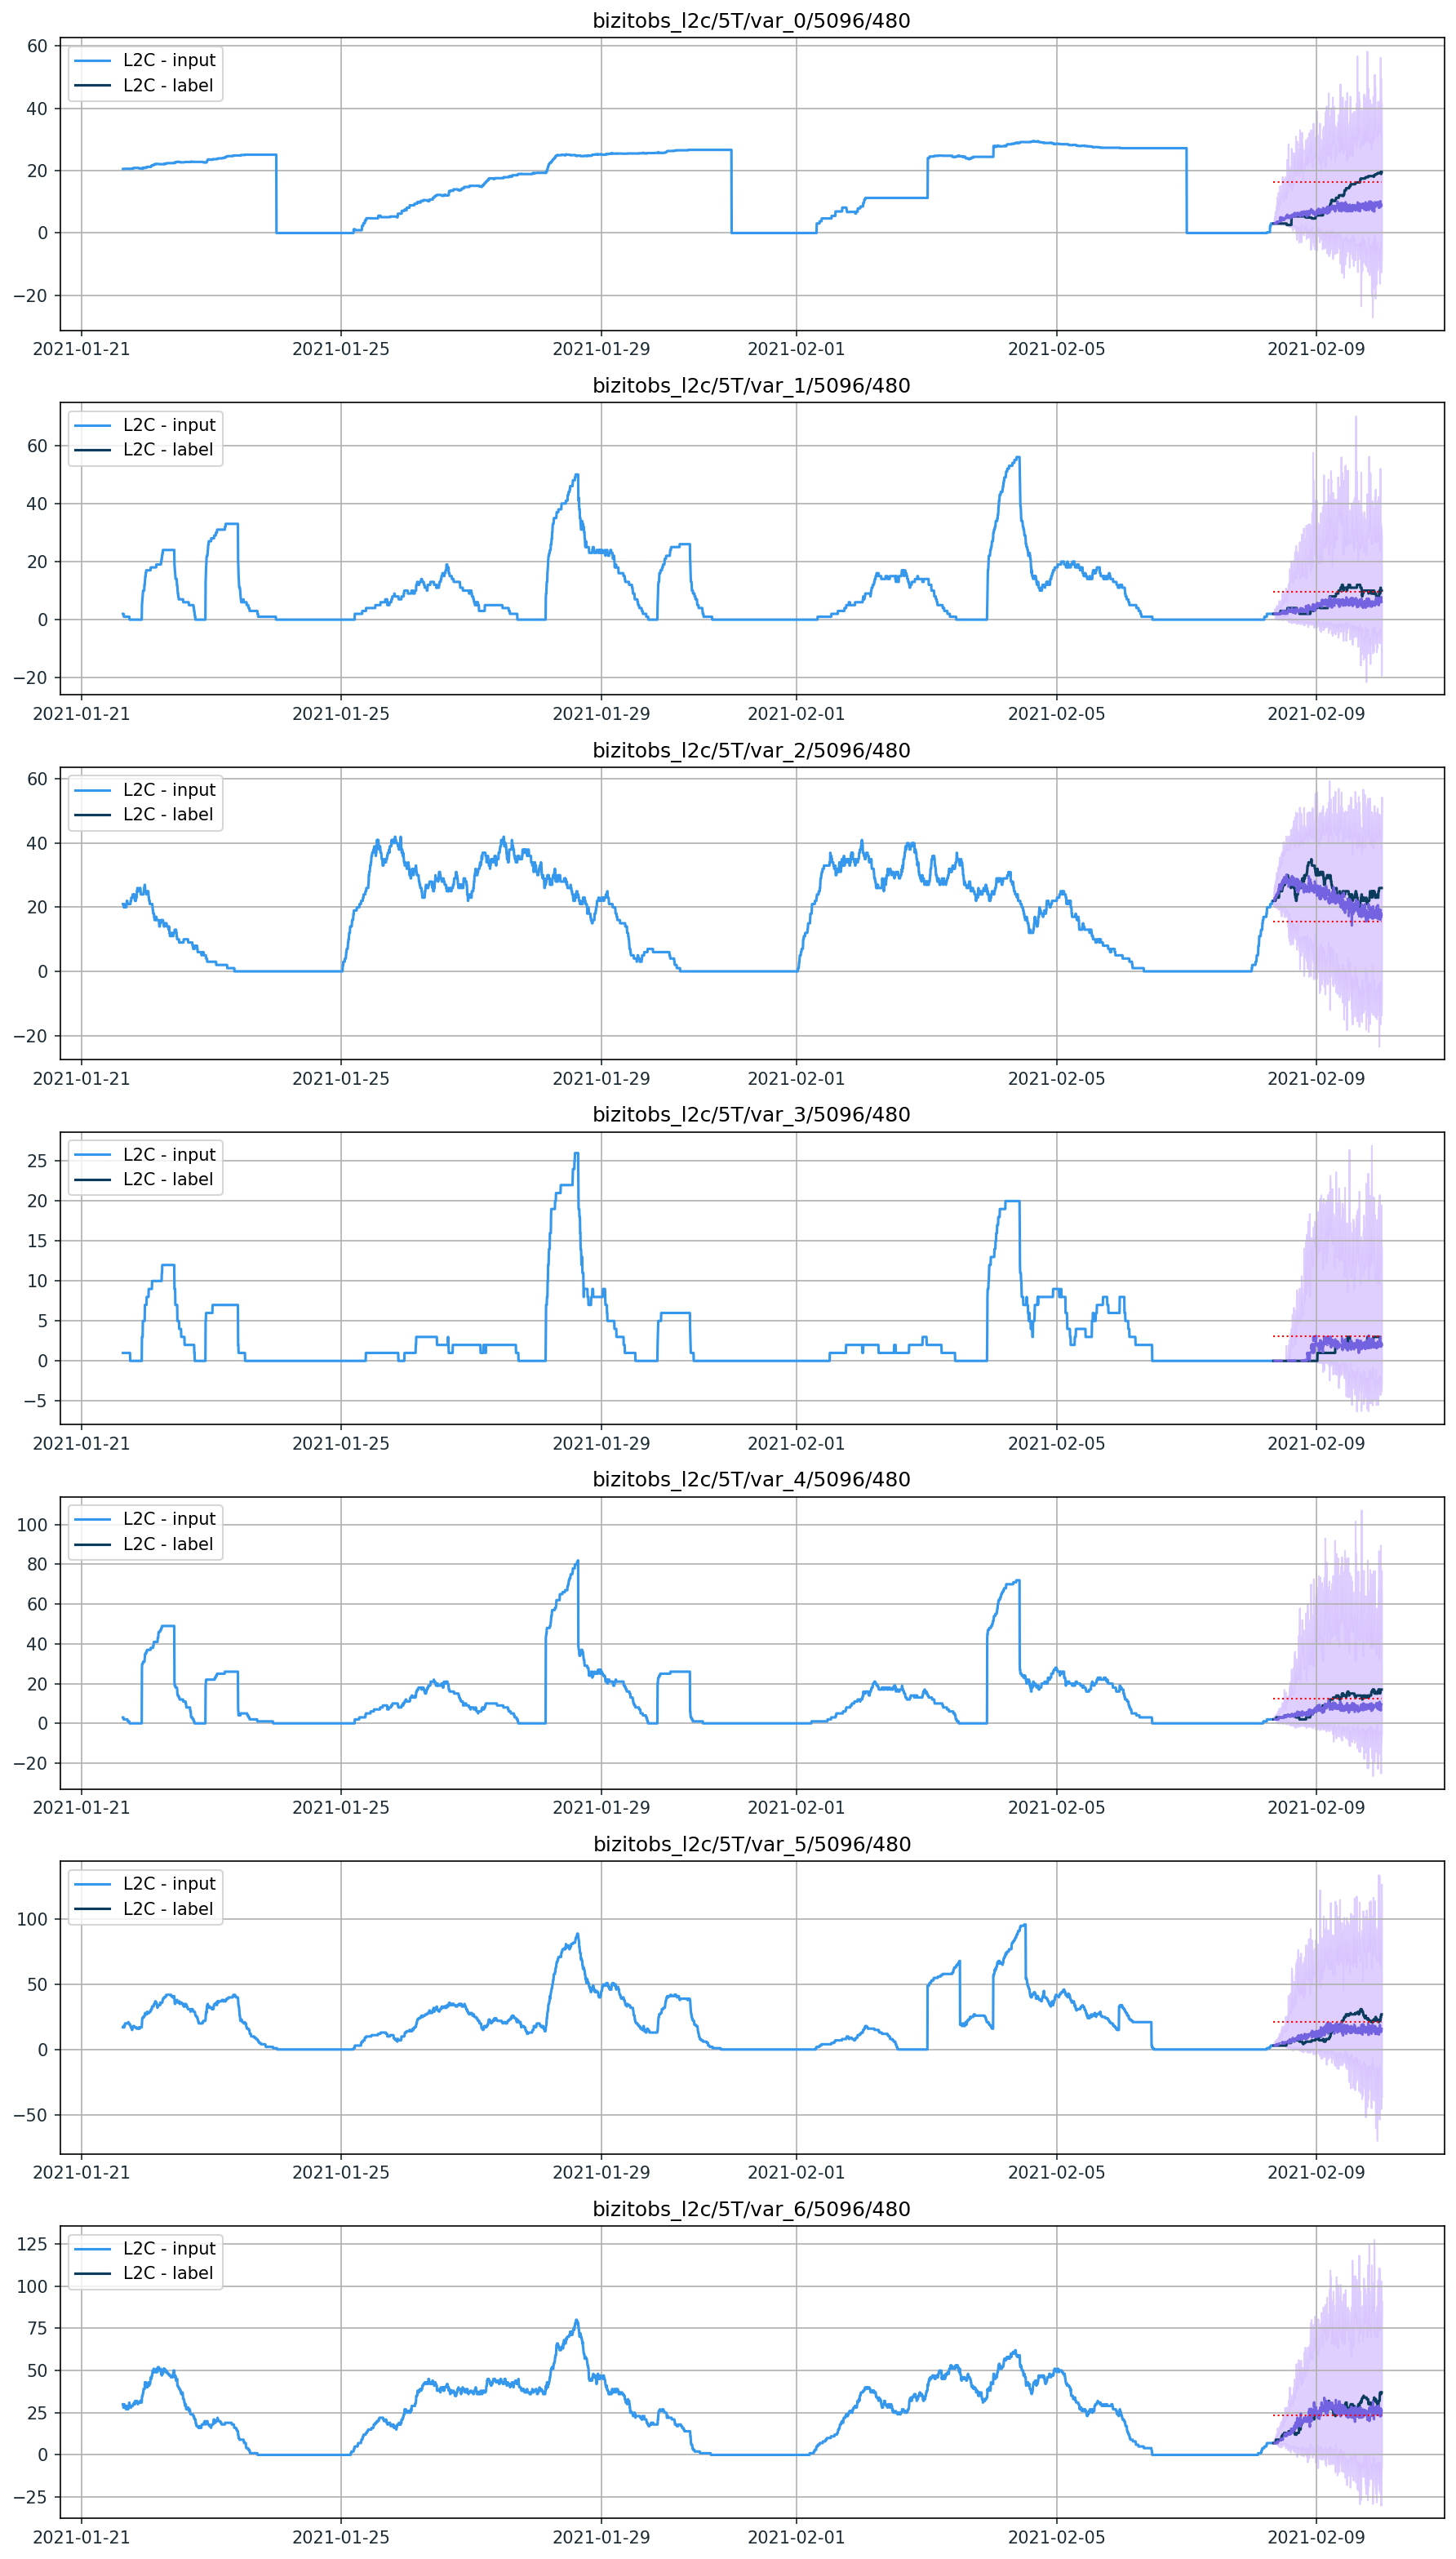

49it [00:00, 3550.14it/s]


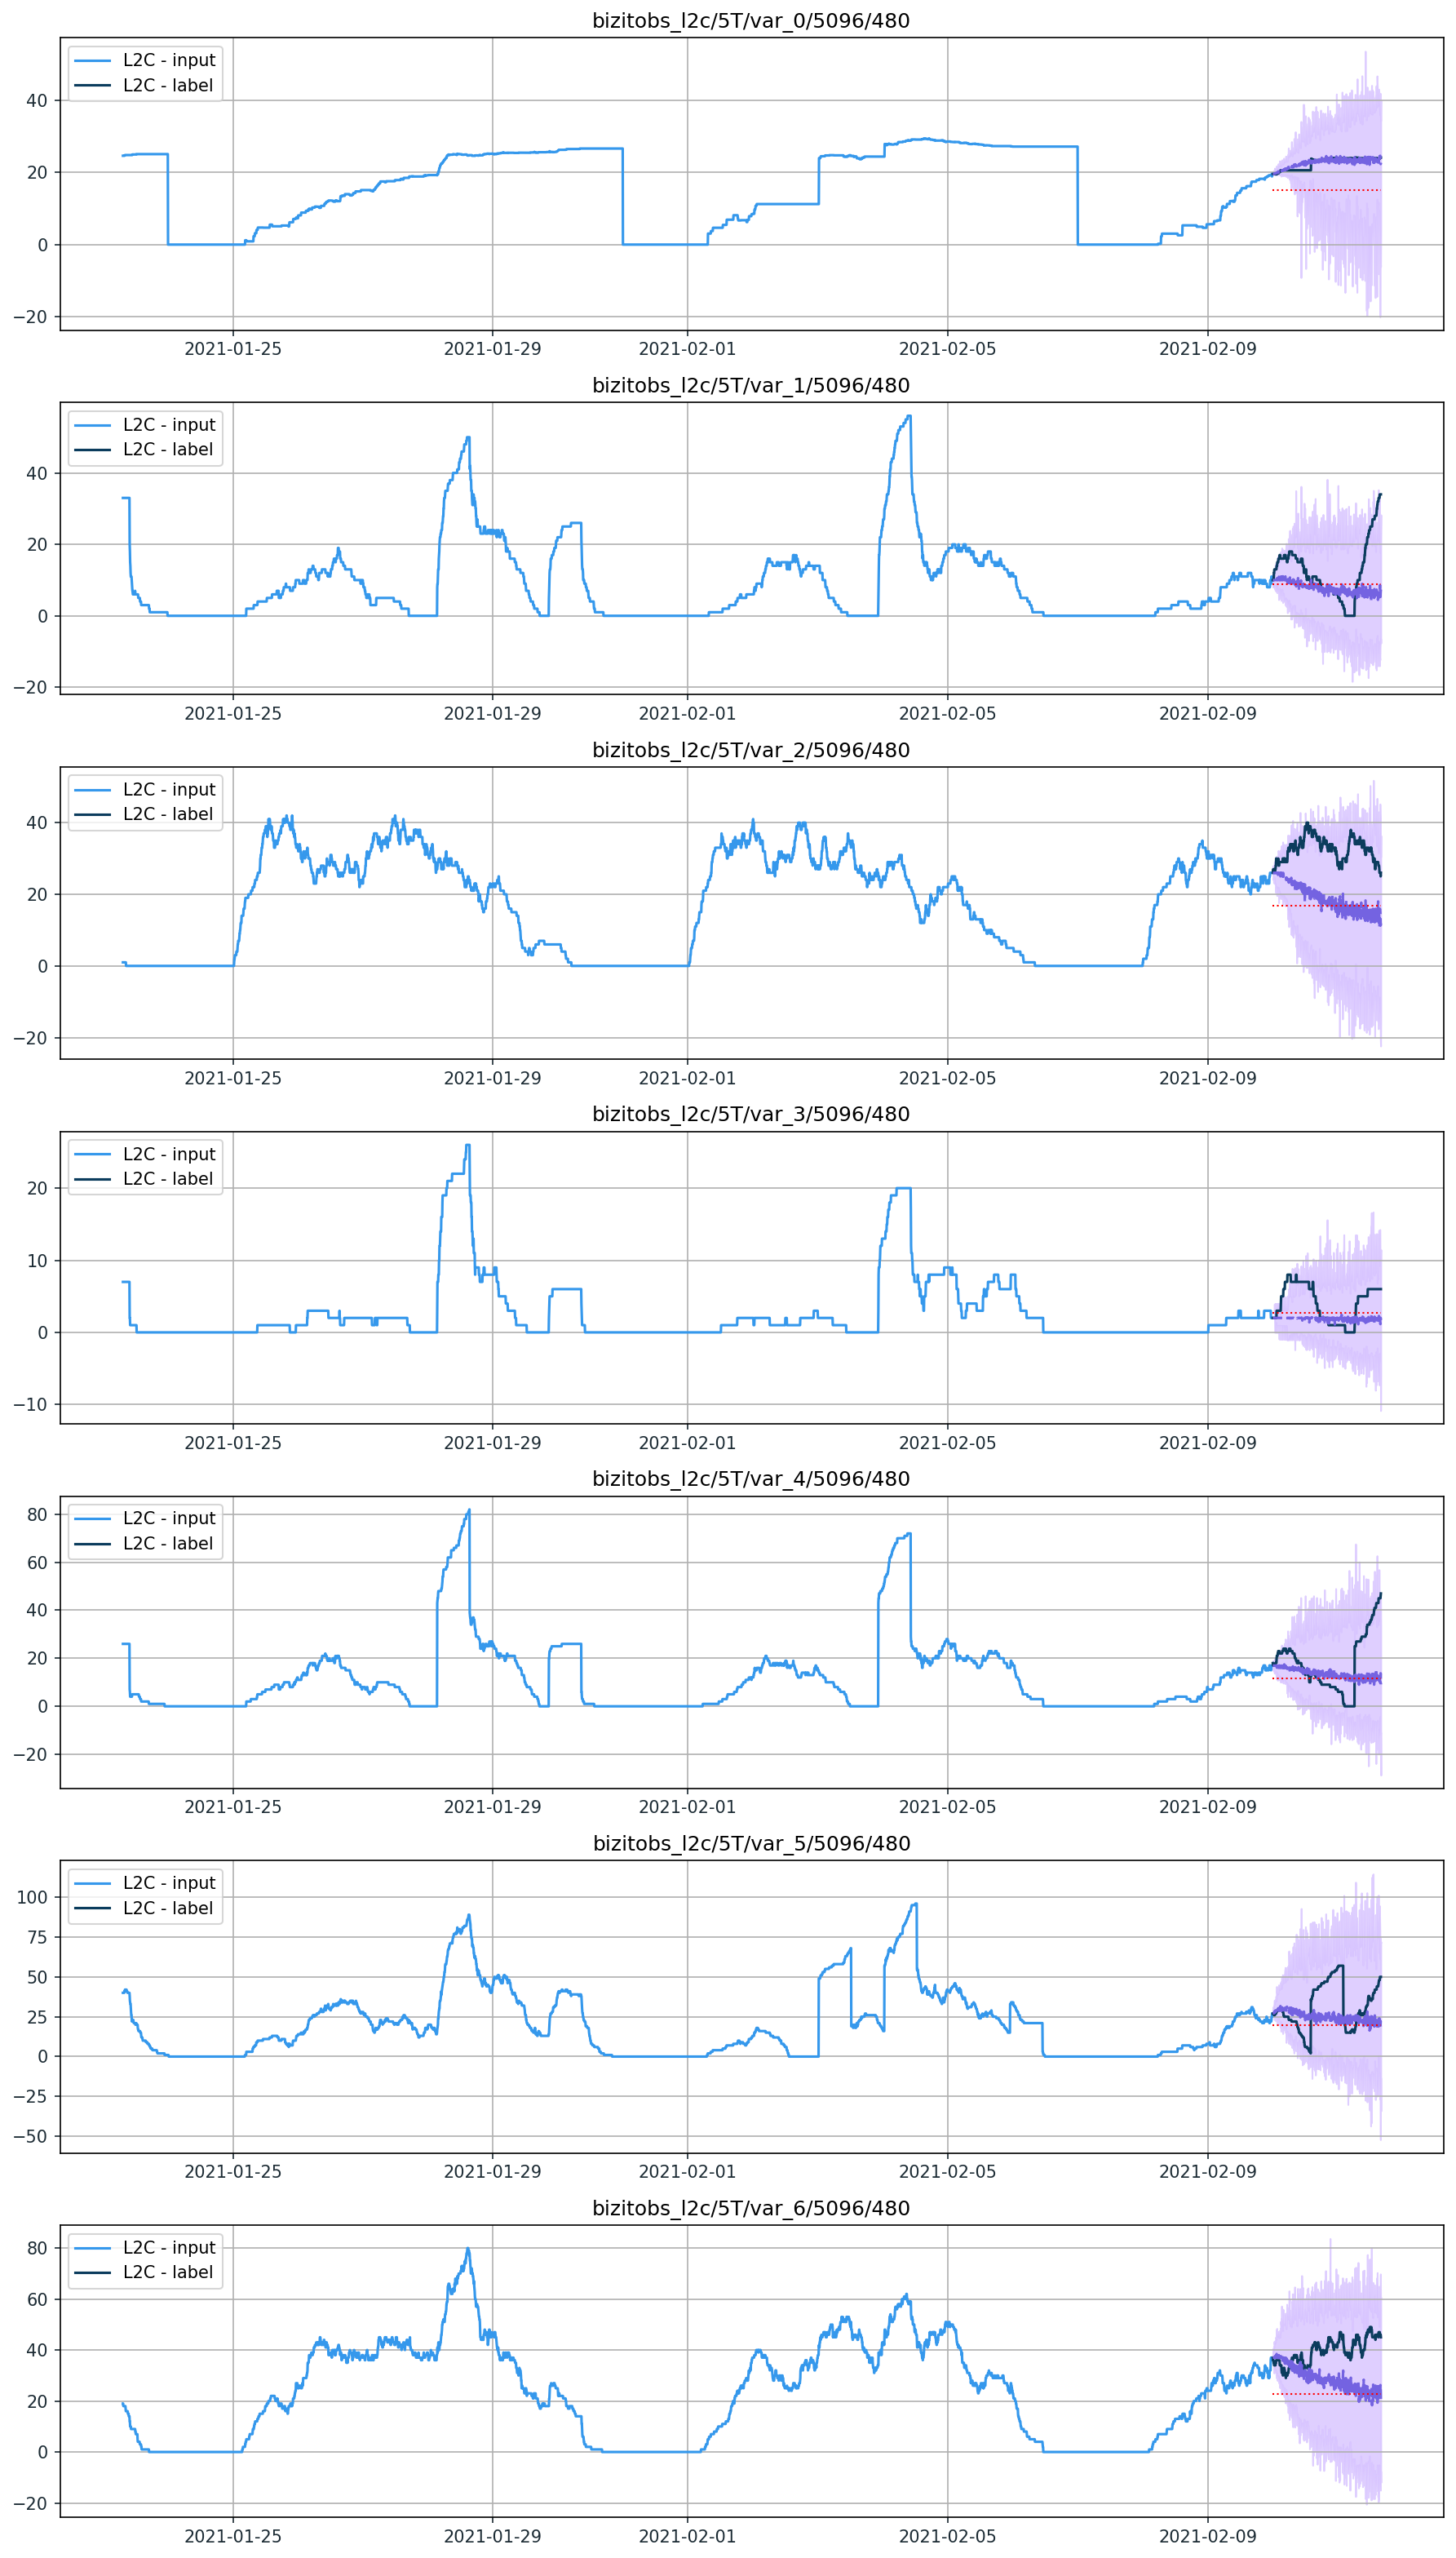

49it [00:00, 3512.52it/s]


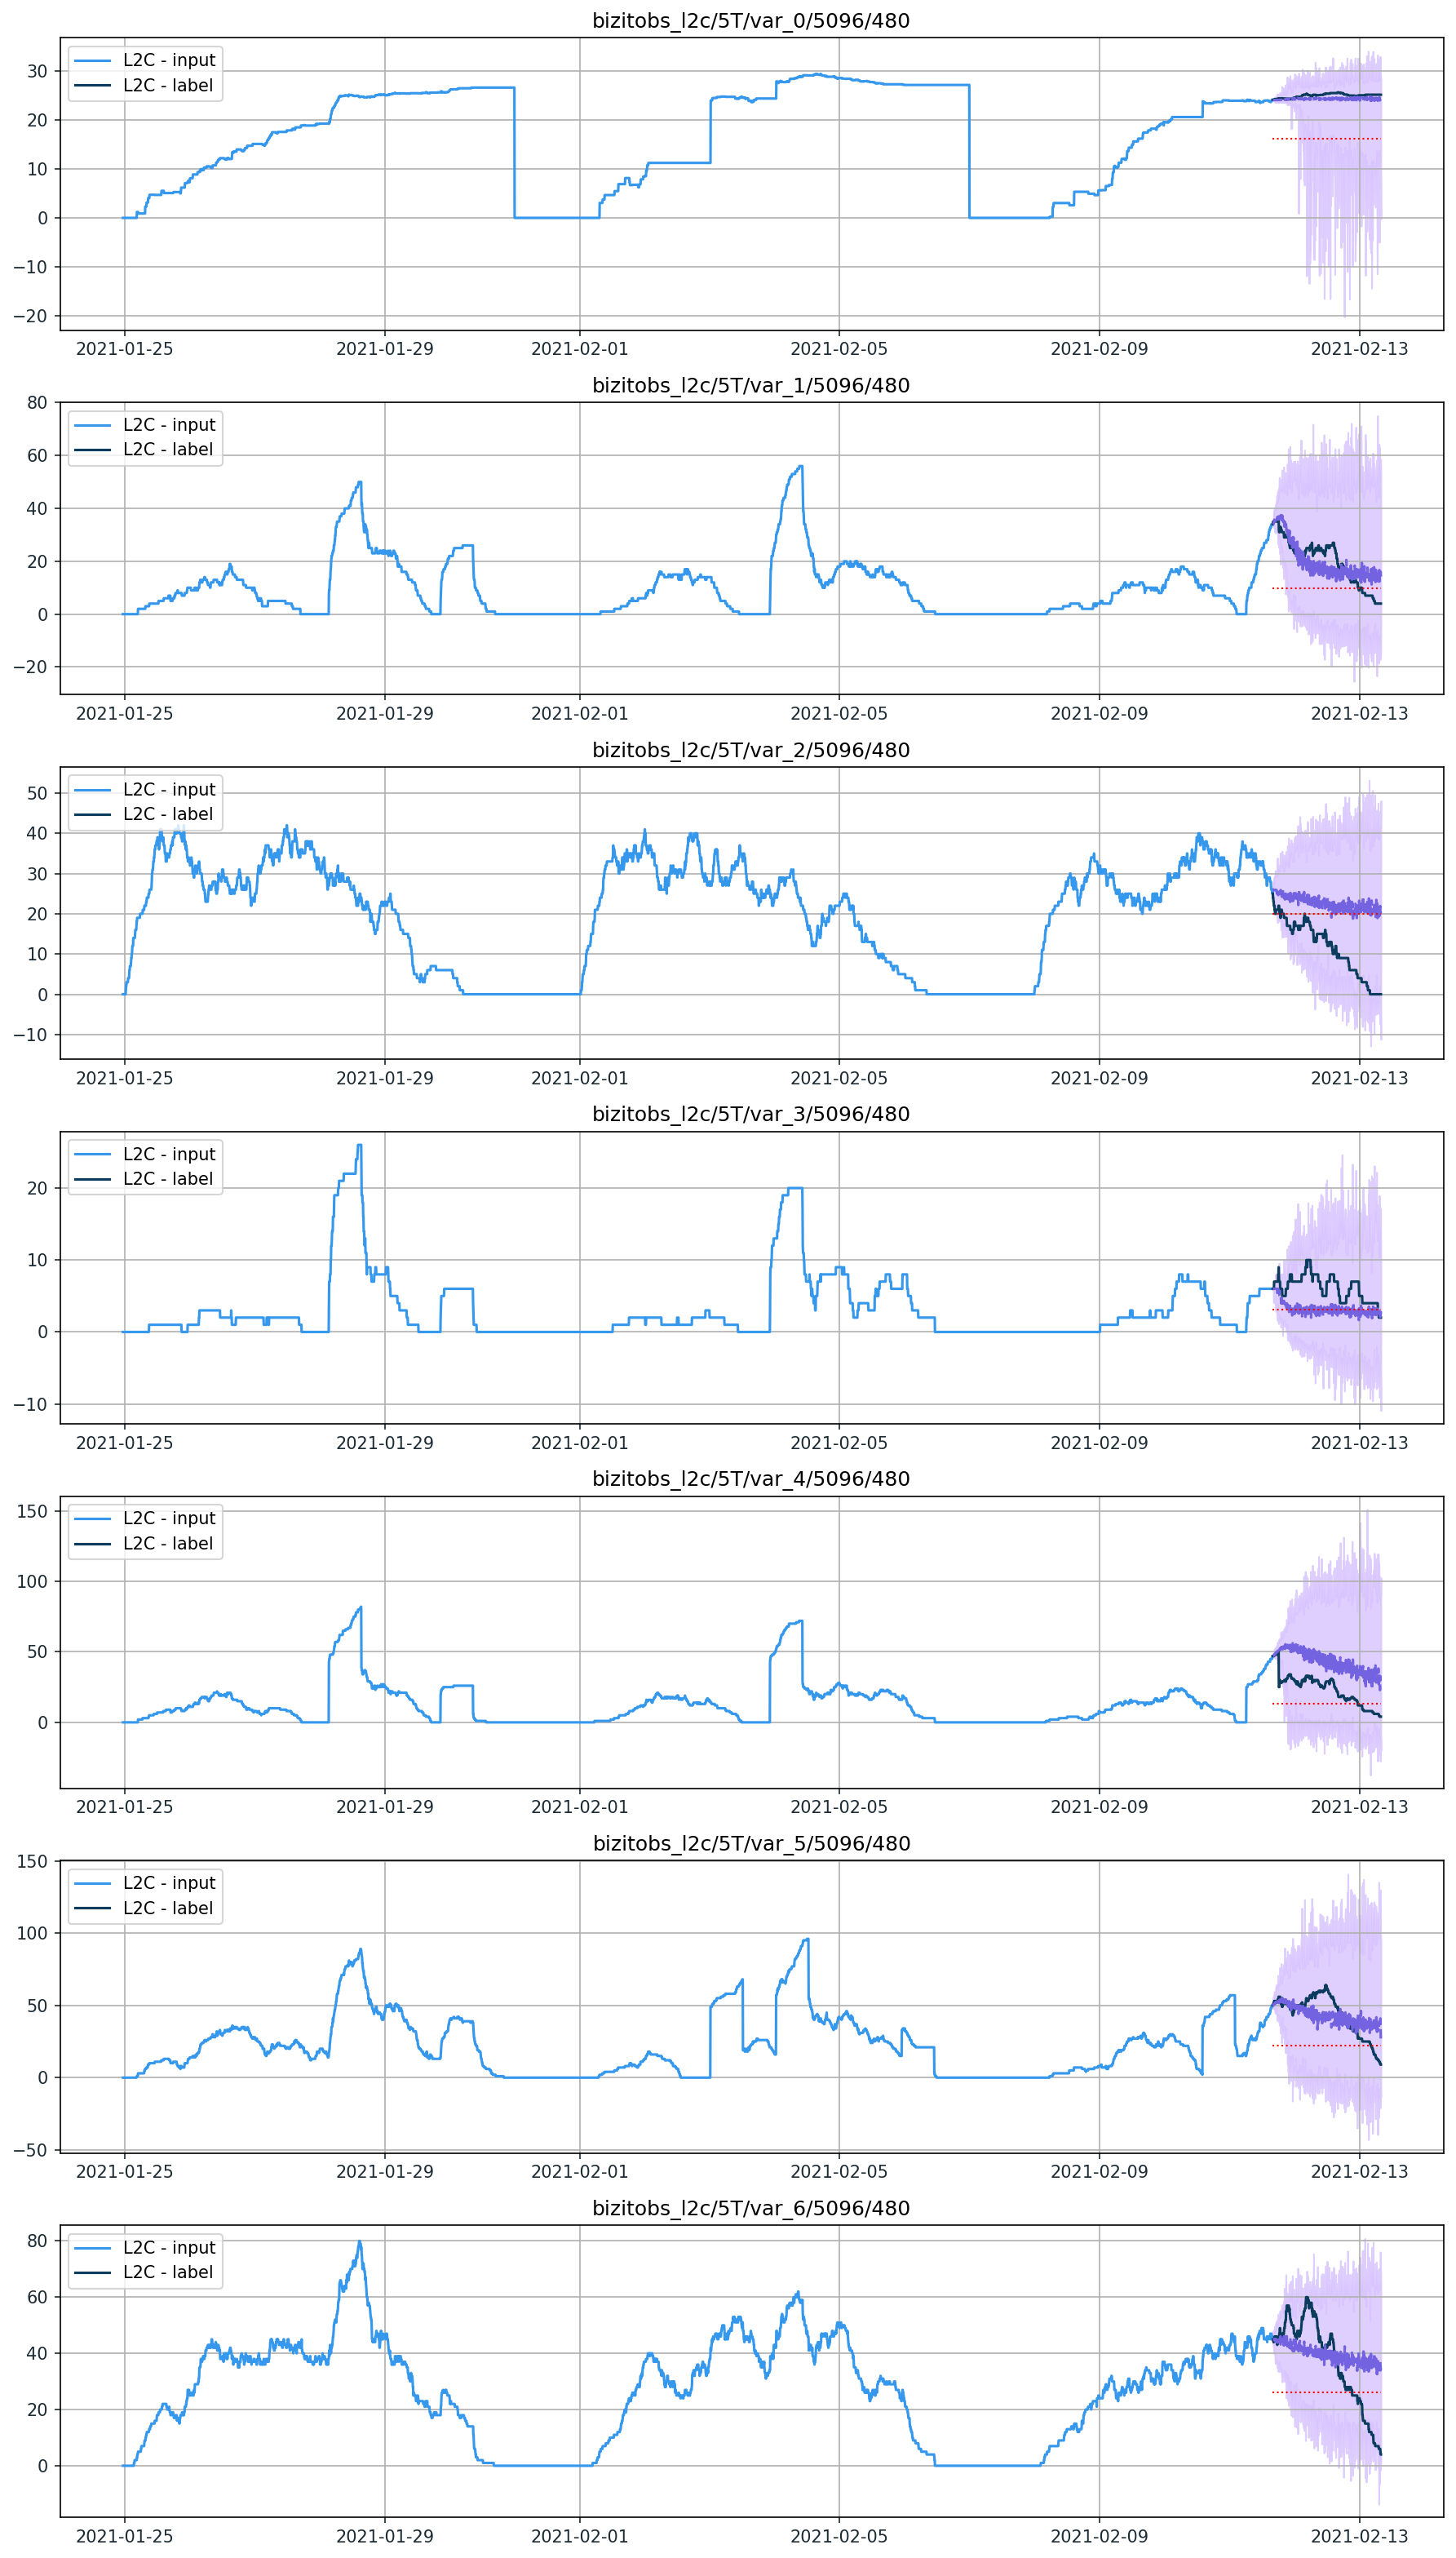

49it [00:00, 3430.61it/s]


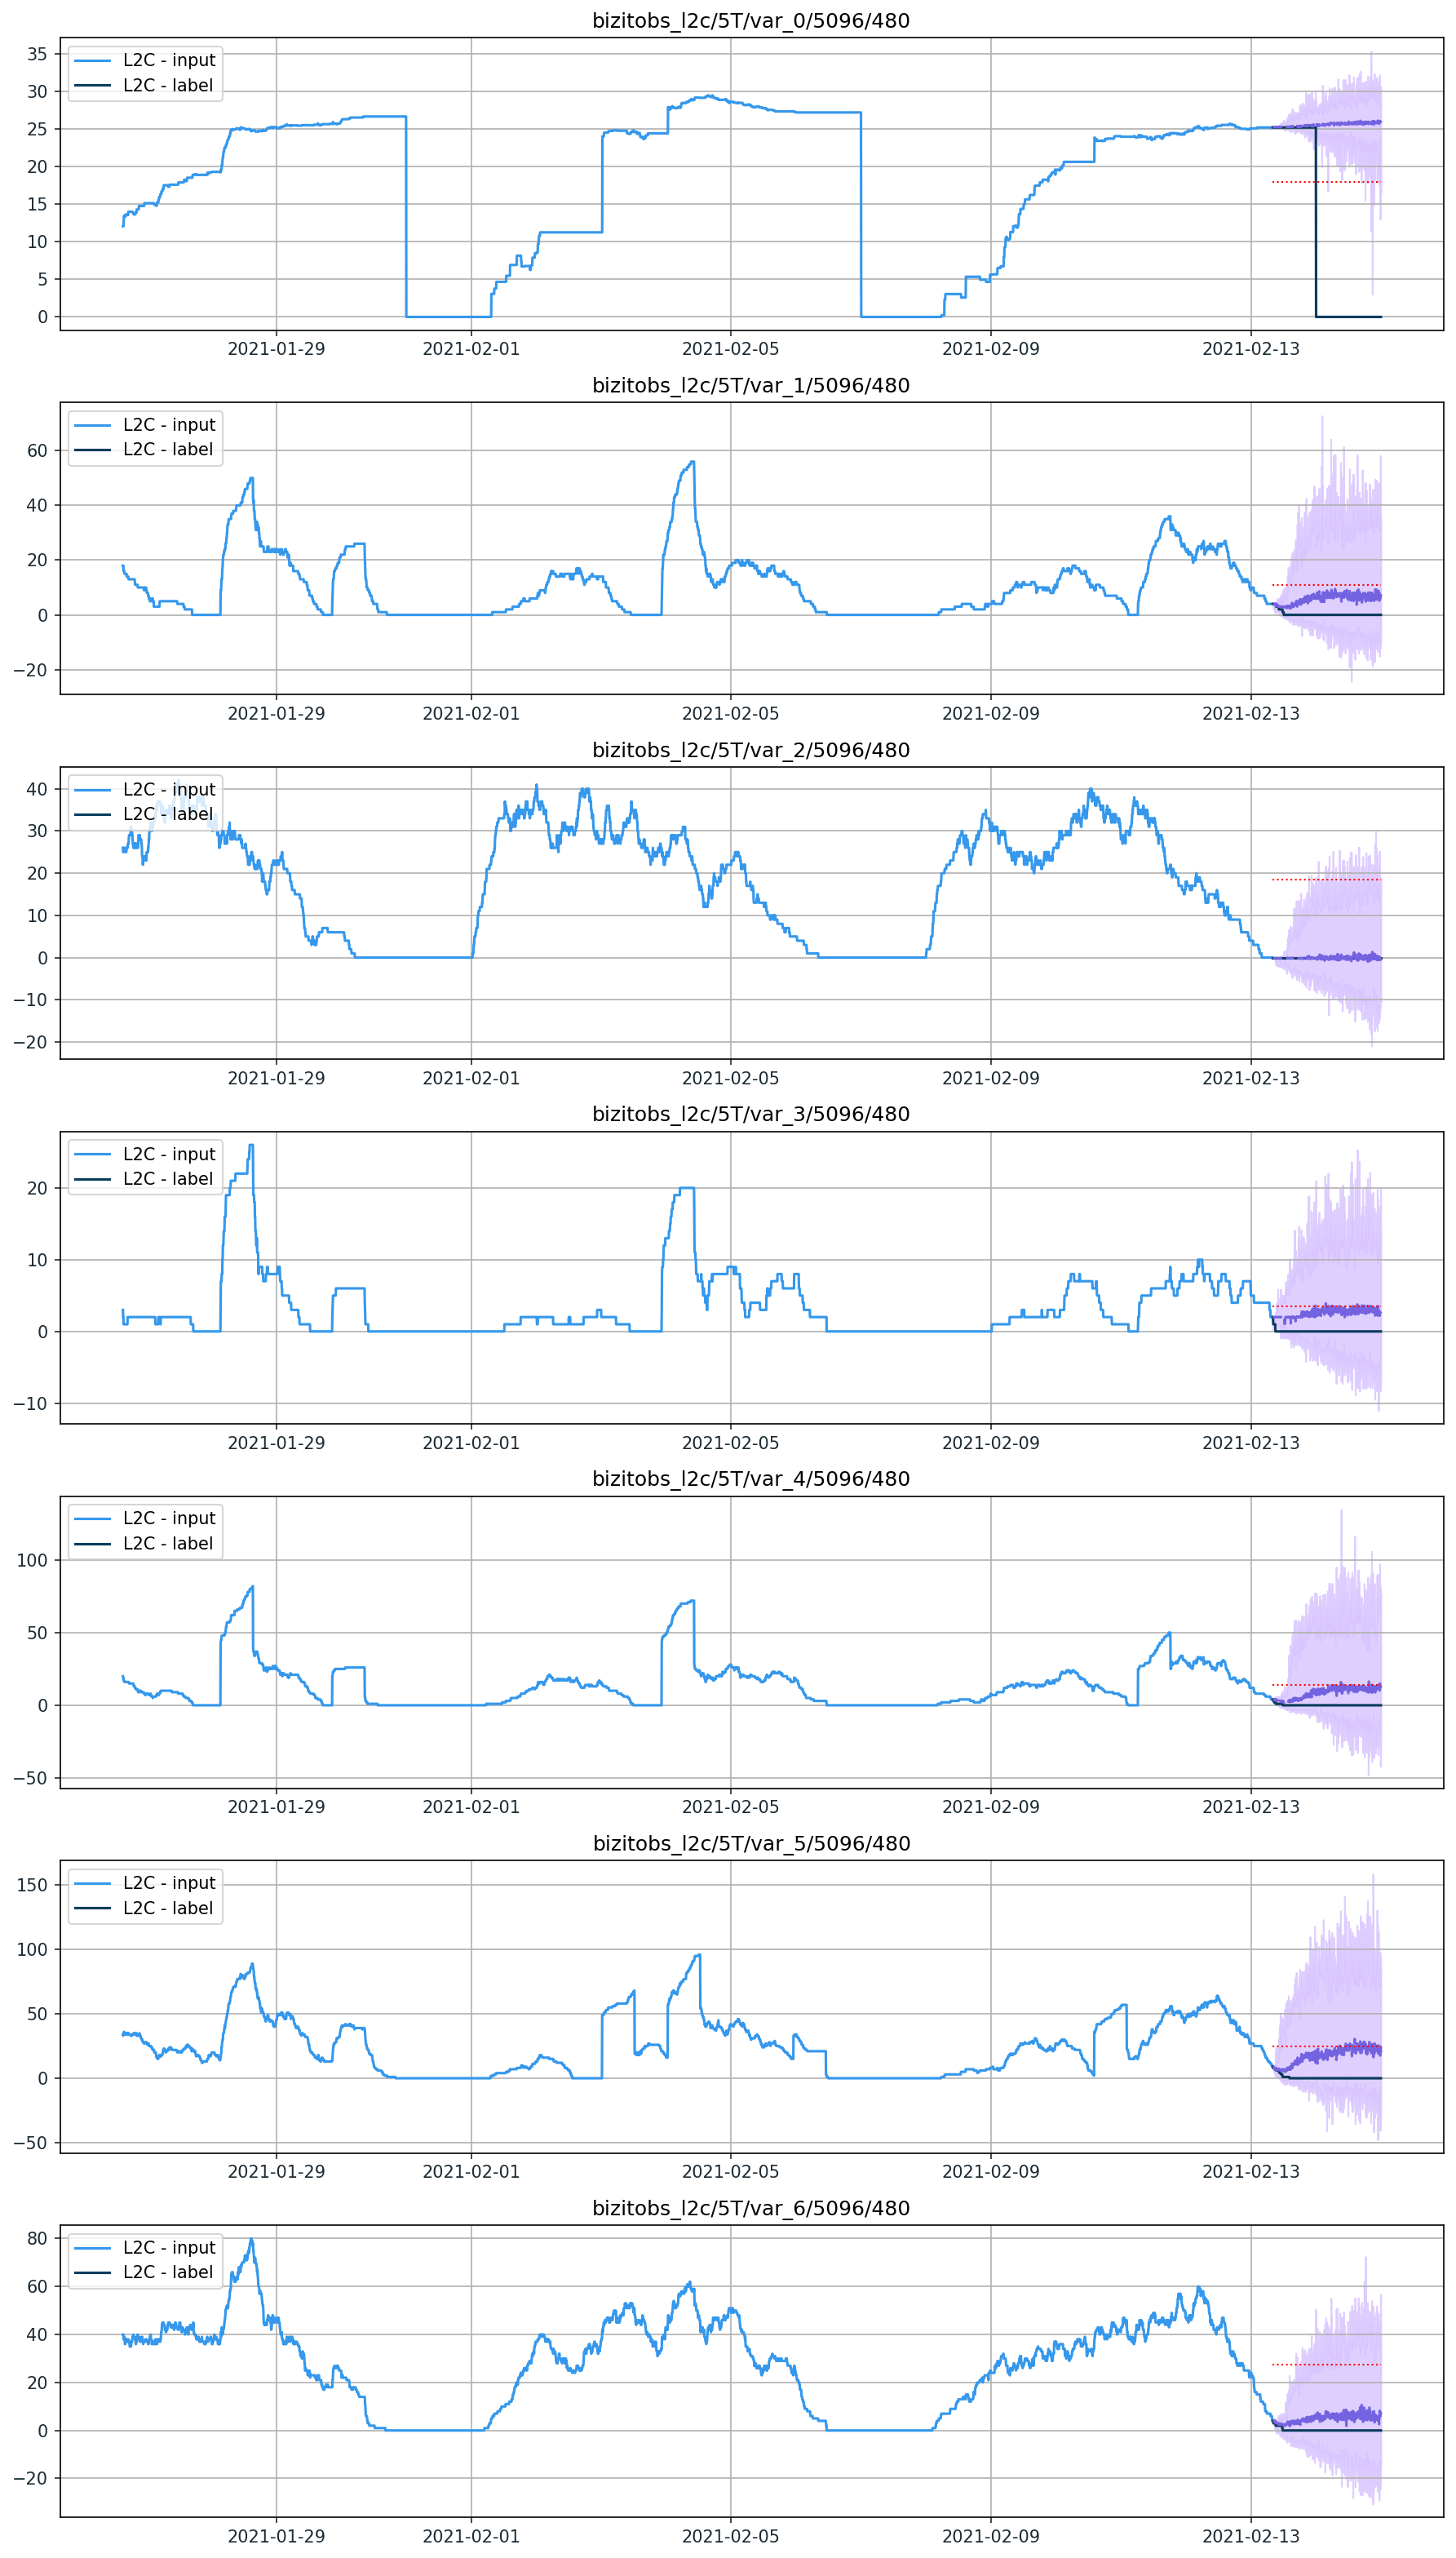

49it [00:00, 3225.22it/s]


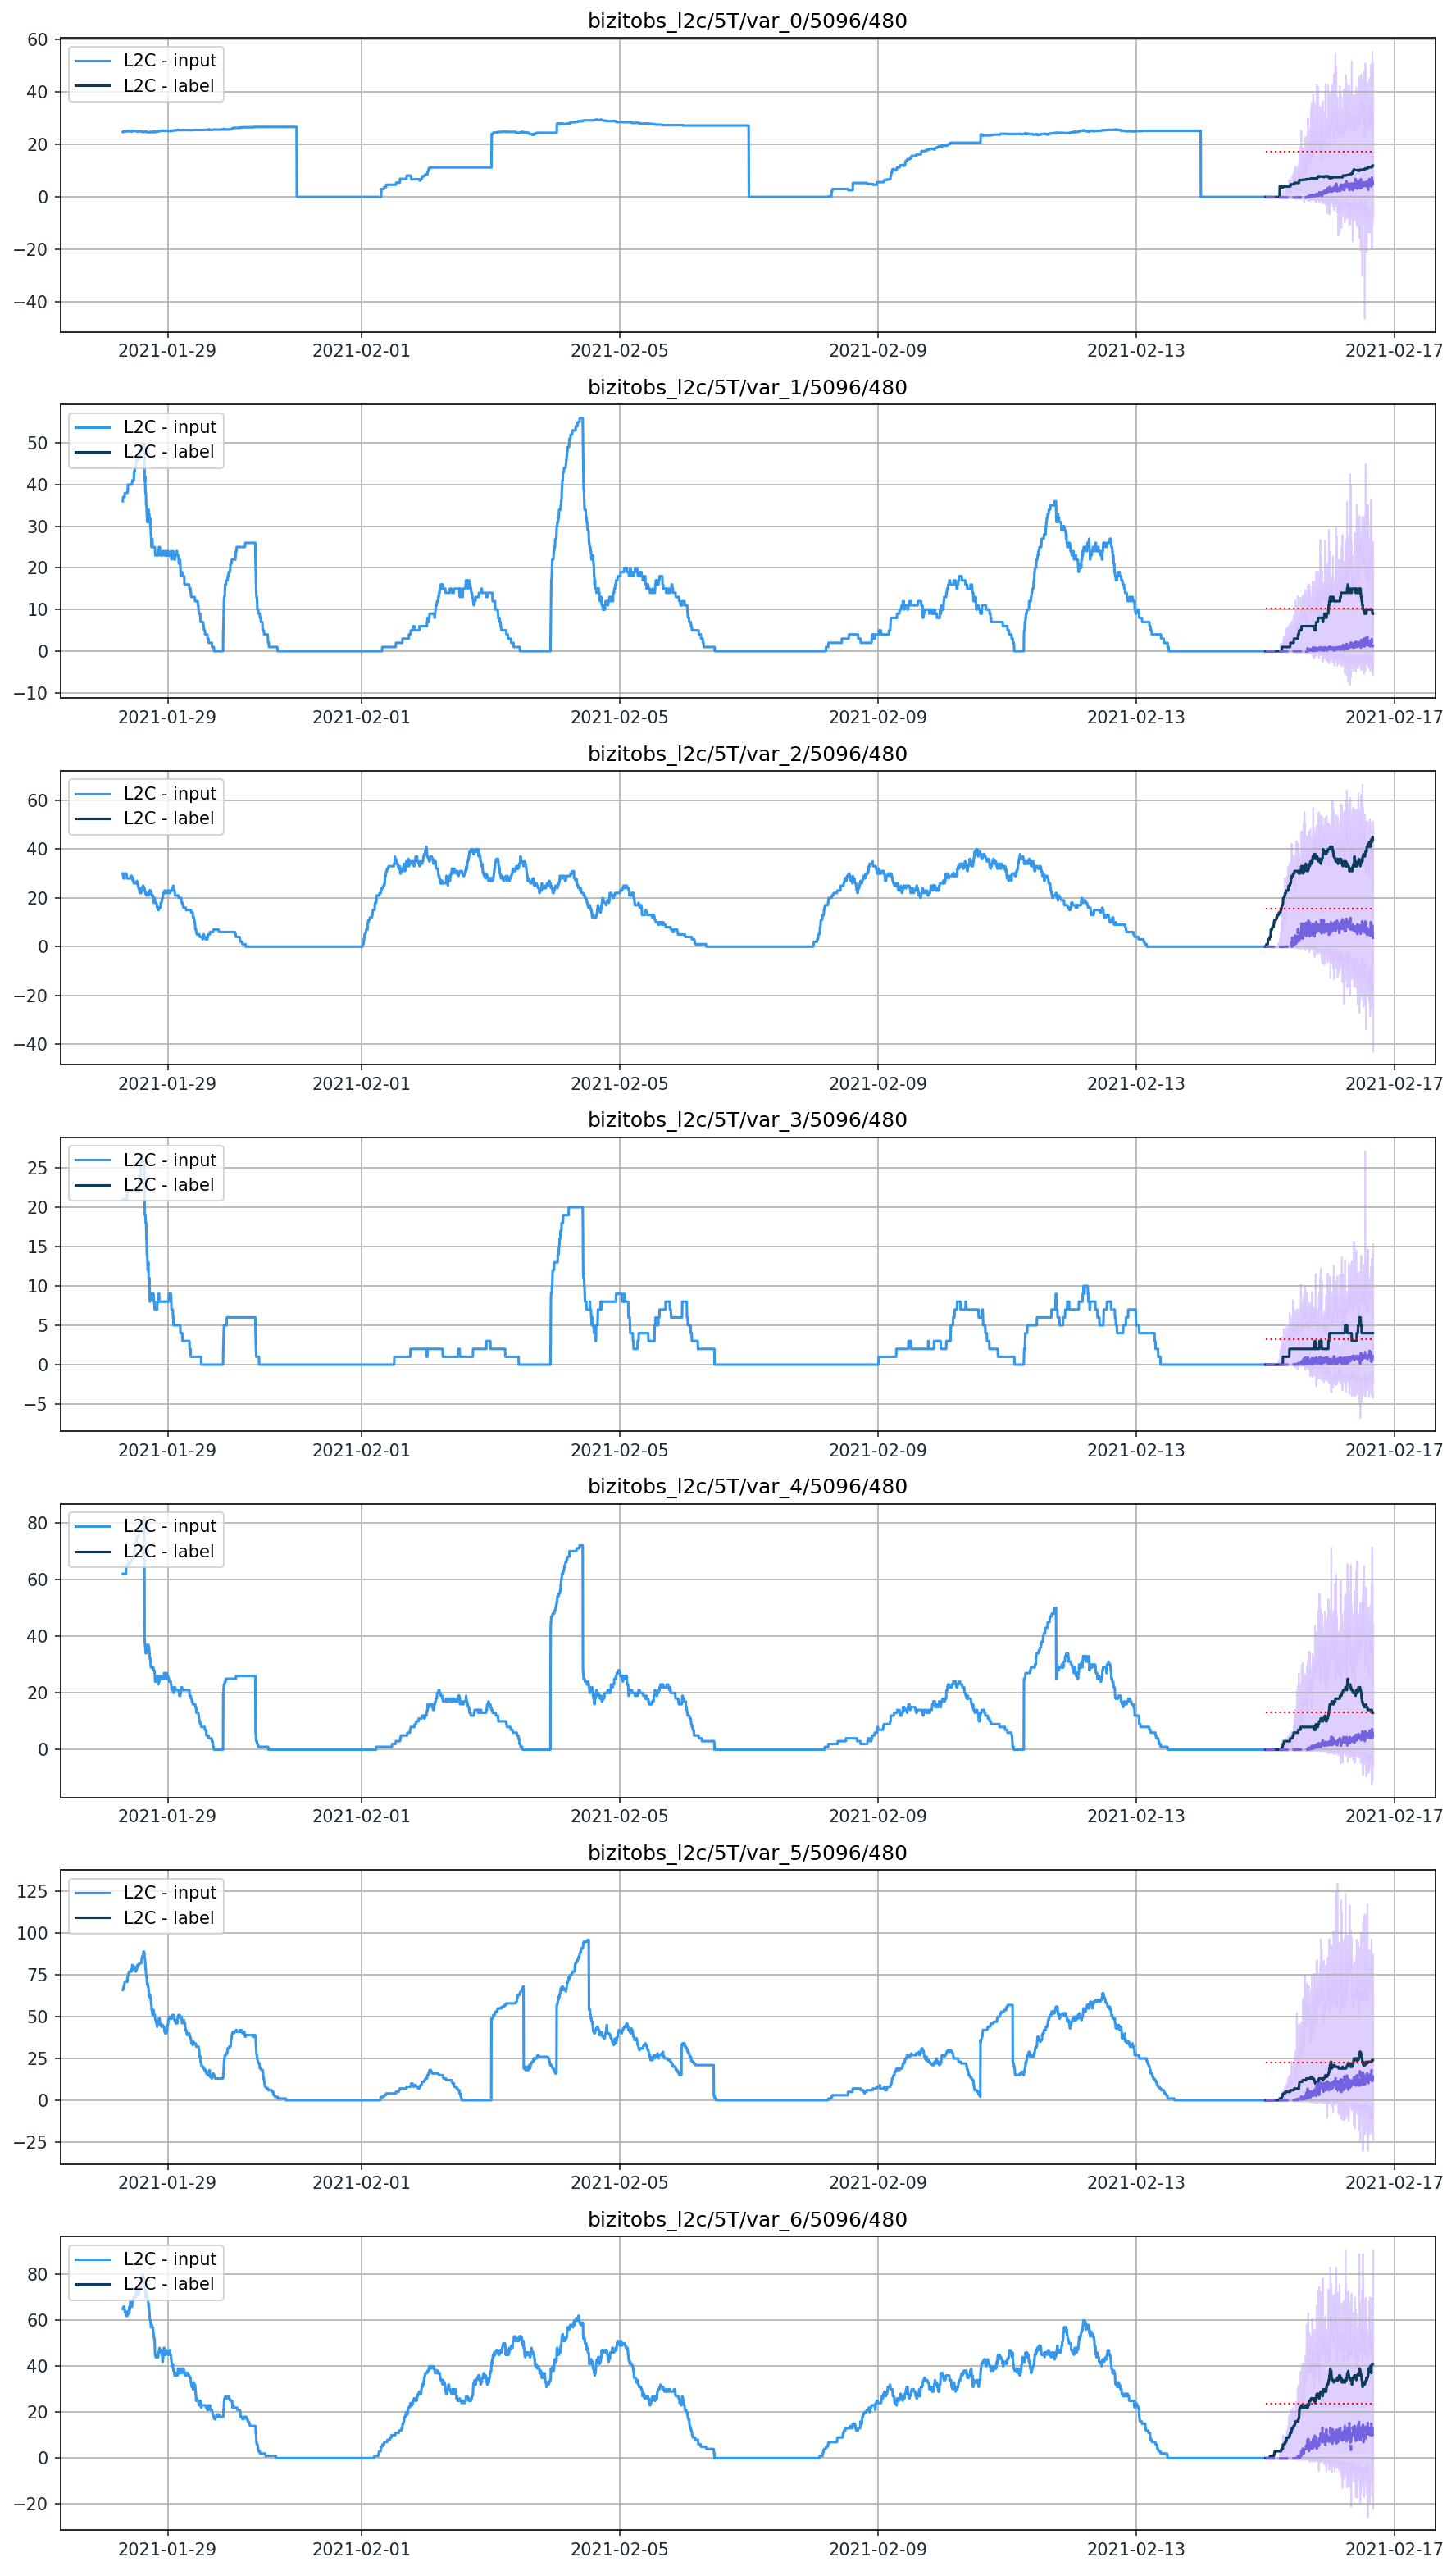

49it [00:00, 3509.46it/s]


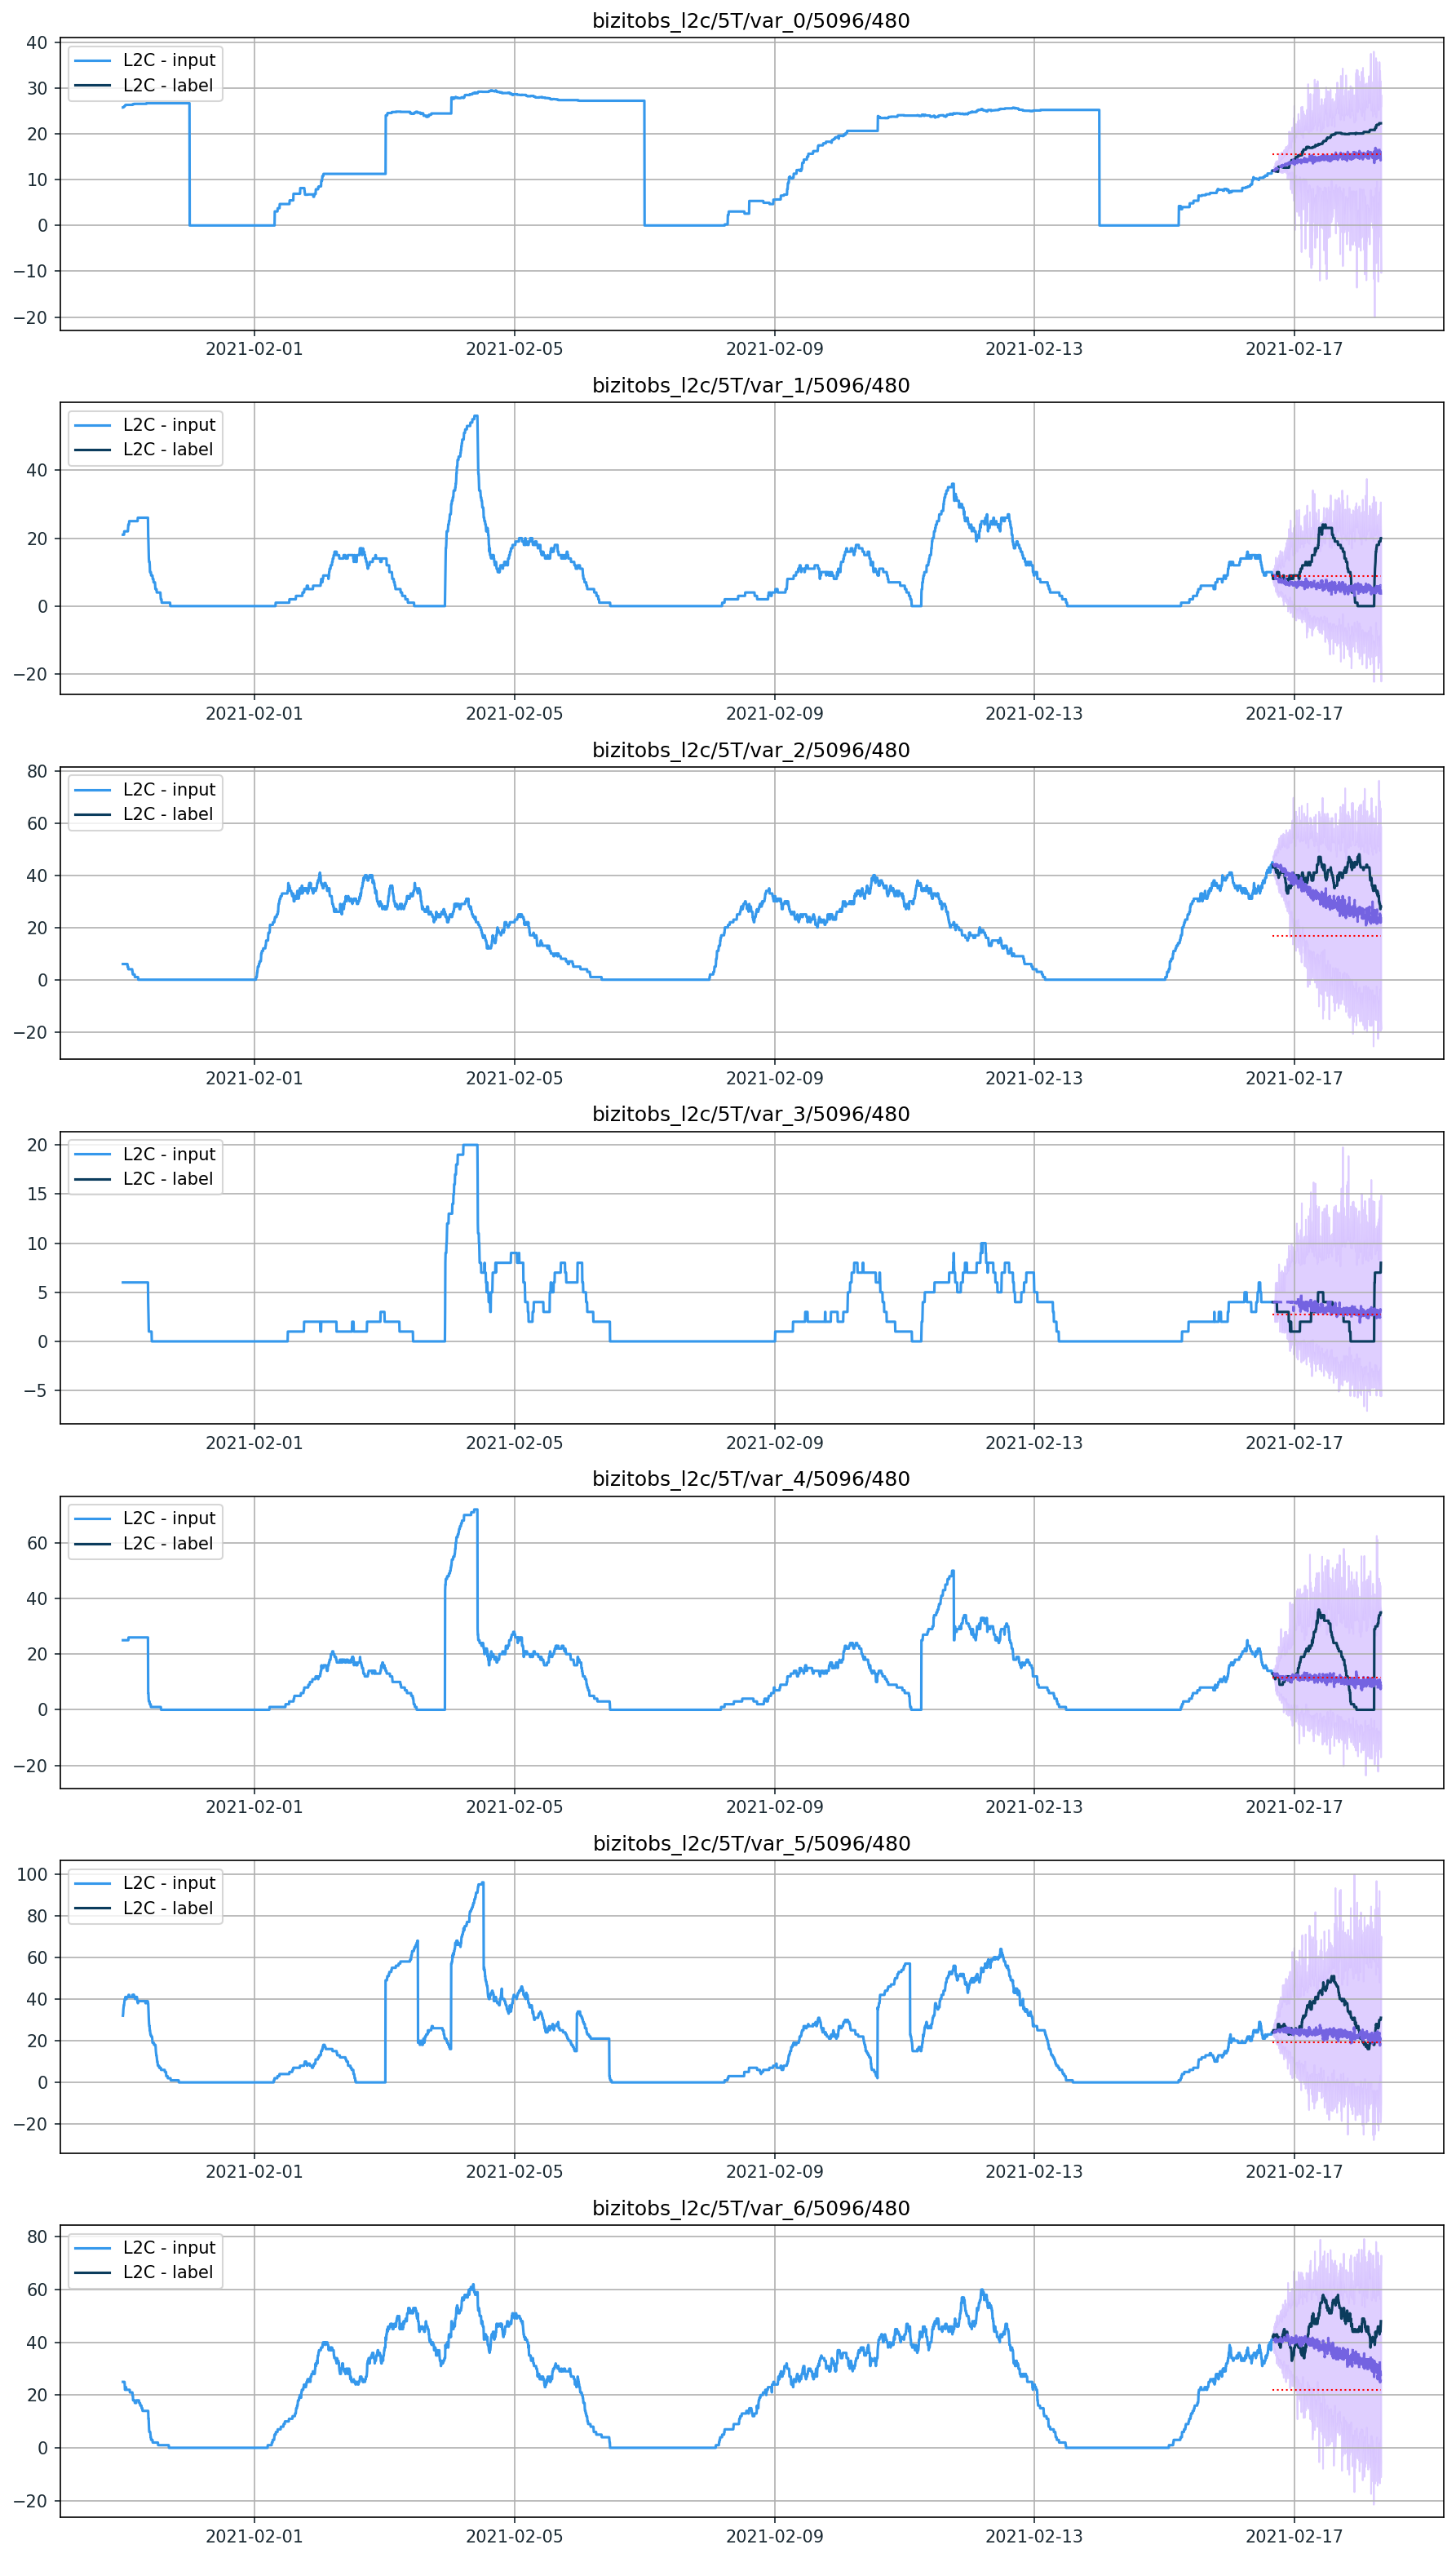

49it [00:00, 3330.59it/s]


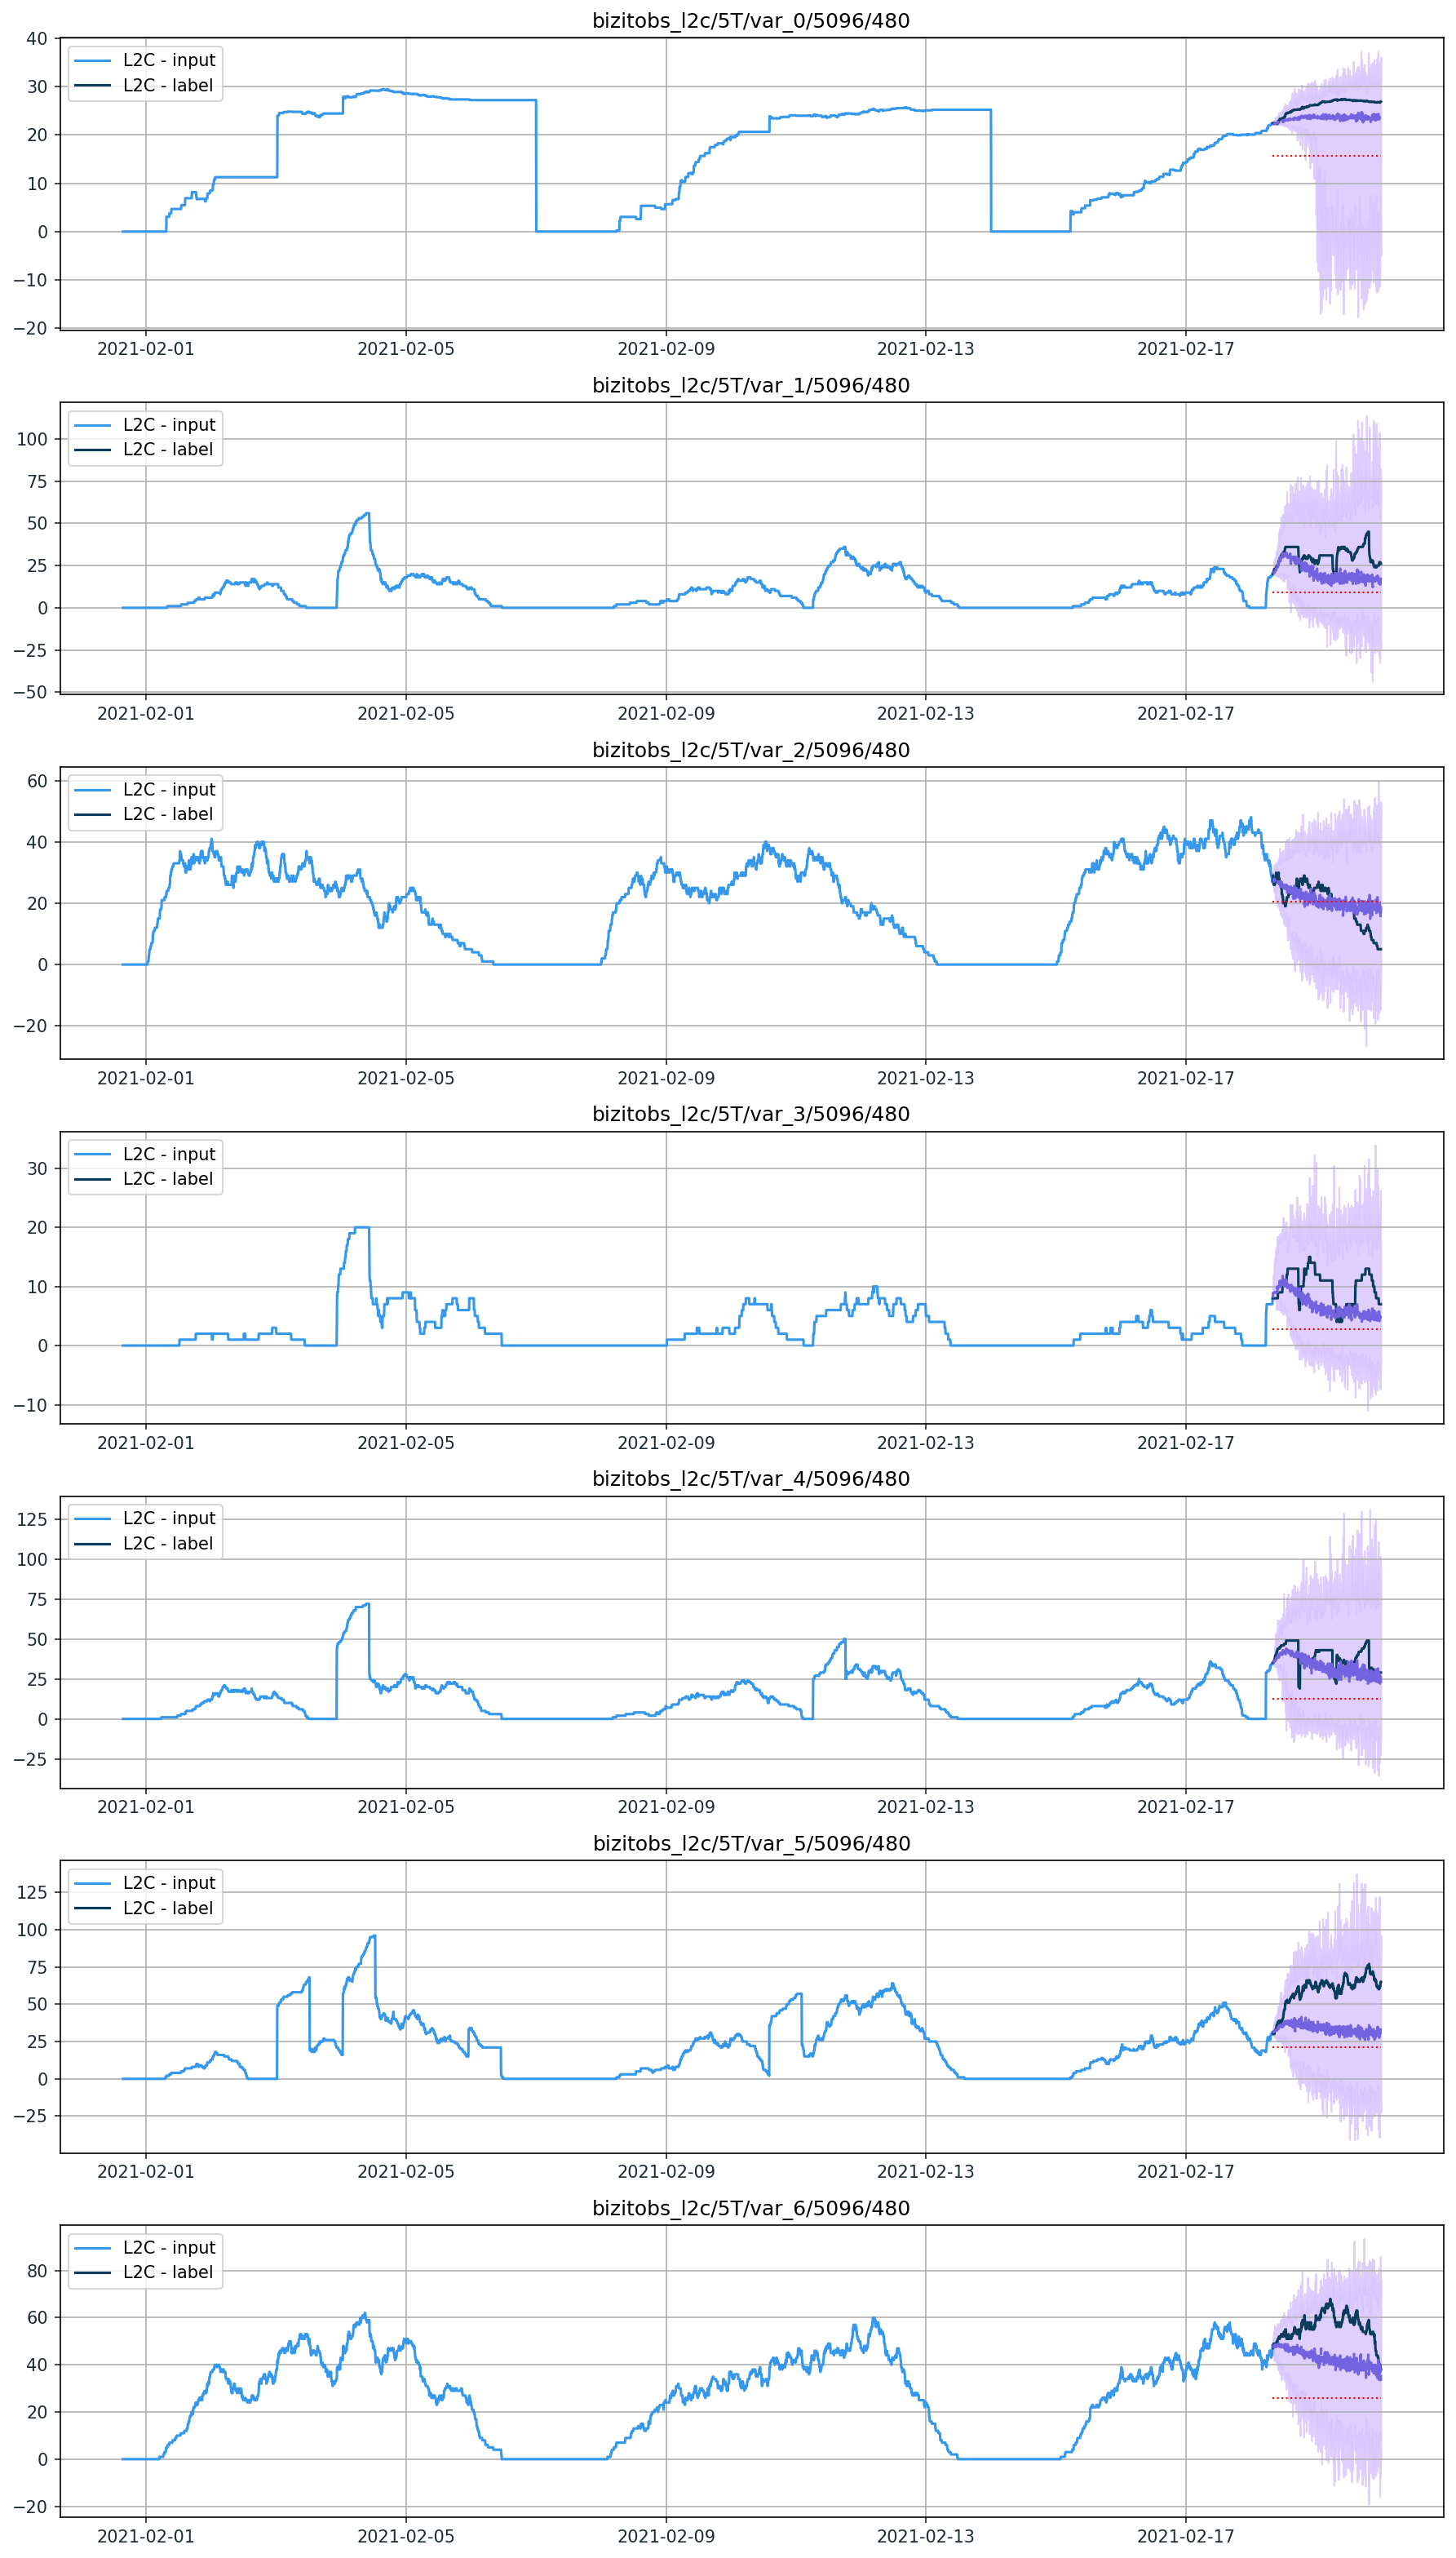

INFO:root:
--- ✅ All evaluations complete. ---


,dataset,variate,num_variates,model,eval_metrics/MAR[0.5][5096],eval_metrics/MBR[0.5][5096],eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],eval_metrics/MSIS,eval_metrics/RMSE[mean],eval_metrics/NRMSE[mean],eval_metrics/ND[0.5],eval_metrics/mean_weighted_sum_quantile_loss
0,bizitobs_l2c/5T/medium,UNI,7,ToTo-GiftEval-sample,1.410669,0.751743,128.971787,128.971787,7.891427,0.762418,0.490118,0.780992,6.827461,11.356575,0.597523,0.415205,0.318522


In [8]:
logging.basicConfig(level=logging.INFO)

# --- Load configuration ---
config_path = "configs/experiments/personal/find_examples.yaml"

config = load_config(config_path)

# --- Set up the evaluation pipeline ---
pipeline = TsPipeline(config)
pipeline.run(skip_existing=False, num_visualization=999)

pipeline.get_results()


In [ ]:
config.experiment_name

'gift_eval_mar_mbr_full_20251017-171624'

In [ ]:
import pandas as pd
df_results = pd.read_csv(f"{REPO_ROOT}/results/{config.experiment_name}/{config.forecaster.alias}/all_results.csv")
df_results

,dataset,variate,num_variates,model,eval_metrics/MSE[mean],eval_metrics/MSE[0.5],eval_metrics/MAE[0.5],eval_metrics/MASE[0.5],eval_metrics/MAPE[0.5],eval_metrics/sMAPE[0.5],...,eval_metrics/MSE[0.5]_all,eval_metrics/MAE[0.5]_all,eval_metrics/MASE[0.5]_all,eval_metrics/MAPE[0.5]_all,eval_metrics/sMAPE[0.5]_all,eval_metrics/MSIS_all,eval_metrics/RMSE[mean]_all,eval_metrics/NRMSE[mean]_all,eval_metrics/ND[0.5]_all,eval_metrics/mean_weighted_sum_quantile_loss_all
0,bizitobs_l2c/H,MULTI,7,ToTo-GiftEval-sample,440.043383,440.043383,16.191903,2.25185,2.137929,1.505732,...,0 440.043383\n1 429.468347\n2 422....,0 16.191903\n1 16.049746\n2 15.867...,0 2.251850\n1 2.203547\n2 2.142641...,0 2.137929\n1 1.707162\n2 1.314620...,0 1.505732\n1 1.492889\n2 1.450249...,0 77.151851\n1 67.392044\n2 54.383...,0 20.977211\n1 20.723618\n2 20.552...,0 1.456277\n1 1.427518\n2 1.395066...,0 1.124072\n1 1.105564\n2 1.077096...,0 1.094789\n1 1.055535\n2 1.007165...


In [16]:
df_results['eval_metrics/MAE[0.5]_all'][0]

'0     16.191903\n1     16.049746\n2     15.867692\n3     15.939789\n4     15.868829\n5     15.185202\n6     14.575236\n7     14.057790\n8     14.385968\n9     14.349109\n10    14.523529\n11    14.199871\n12    14.396627\n13    14.333341\n14    15.398176\n15    15.441875\n16    15.324949\n17    14.658757\n18    14.170233\n19    14.153216\n20    14.340941\n21    14.374166\n22    14.005002\n23    14.305349\n24    14.234480\n25    14.220032\n26    12.959763\n27    12.903173\n28    12.240773\n29    12.451297\n30    12.169081\n31    12.634473\n32    13.475215\n33    13.666390\n34    14.425859\n35    14.369735\n36    14.225695\n37    14.401274\n38    14.408903\n39    14.934228\n40    15.064535\n41    15.496502\n42    15.765365\n43    15.789291\n44    15.147556\n45    15.963046\n46    15.585856\n47    15.159534\nName: MAE[0.5], dtype: float64'

In [18]:
config.evaluation.to_univariate

False